In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv("caravan-insurance-challenge.csv")

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9822 entries, 0 to 9821
Data columns (total 87 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ORIGIN    9822 non-null   str  
 1   MOSTYPE   9822 non-null   int64
 2   MAANTHUI  9822 non-null   int64
 3   MGEMOMV   9822 non-null   int64
 4   MGEMLEEF  9822 non-null   int64
 5   MOSHOOFD  9822 non-null   int64
 6   MGODRK    9822 non-null   int64
 7   MGODPR    9822 non-null   int64
 8   MGODOV    9822 non-null   int64
 9   MGODGE    9822 non-null   int64
 10  MRELGE    9822 non-null   int64
 11  MRELSA    9822 non-null   int64
 12  MRELOV    9822 non-null   int64
 13  MFALLEEN  9822 non-null   int64
 14  MFGEKIND  9822 non-null   int64
 15  MFWEKIND  9822 non-null   int64
 16  MOPLHOOG  9822 non-null   int64
 17  MOPLMIDD  9822 non-null   int64
 18  MOPLLAAG  9822 non-null   int64
 19  MBERHOOG  9822 non-null   int64
 20  MBERZELF  9822 non-null   int64
 21  MBERBOER  9822 non-null   int64
 22  MBERMIDD  9

In [10]:
def show_fig():
    plt.tight_layout()
    plt.show()

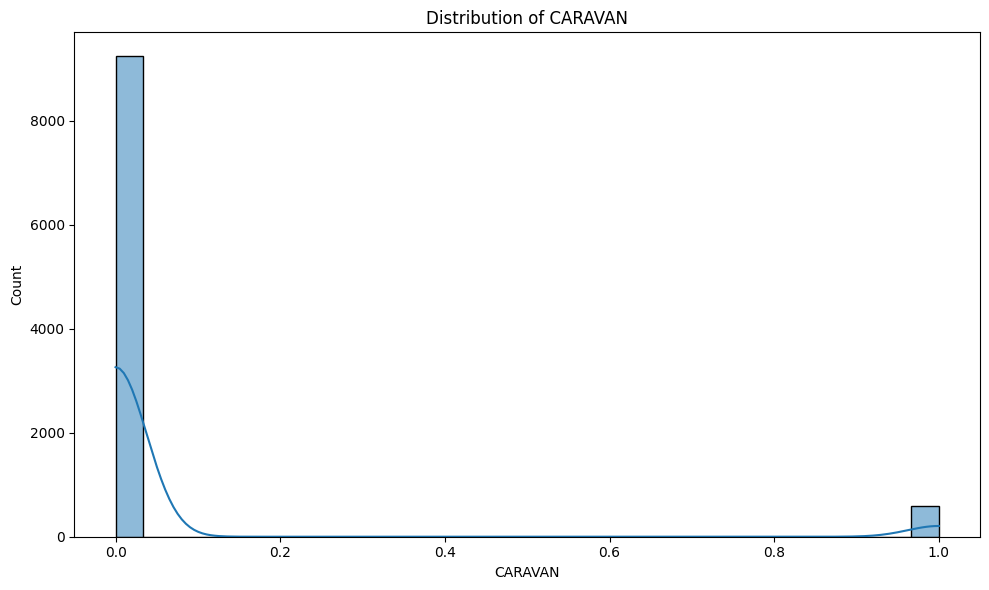

In [11]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data['CARAVAN'], kde=True, bins=30)
plt.title('Distribution of CARAVAN')
show_fig()

In [15]:
y = data['CARAVAN']
X = data.drop(['ORIGIN','CARAVAN'], axis=1)
y.value_counts()

CARAVAN
0    9236
1     586
Name: count, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2309
           1       0.15      0.23      0.18       147

    accuracy                           0.88      2456
   macro avg       0.55      0.57      0.56      2456
weighted avg       0.90      0.88      0.89      2456

[[2117  192]
 [ 113   34]]


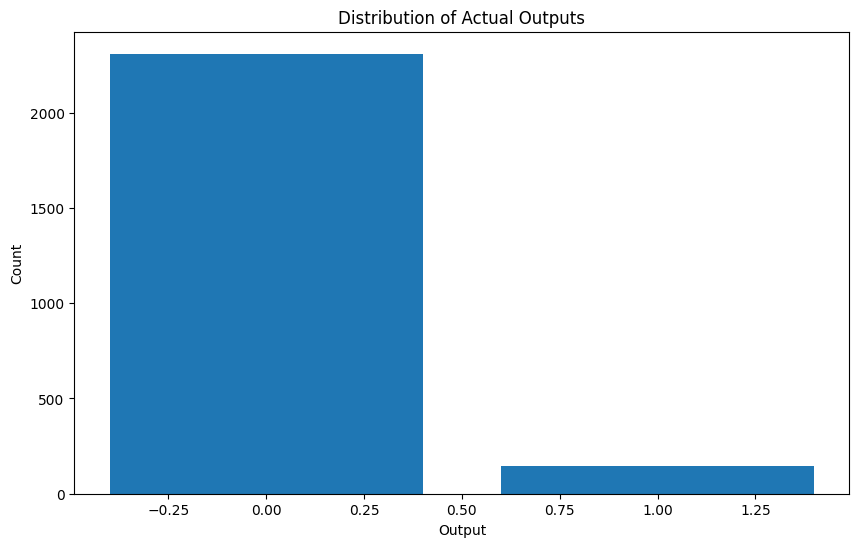

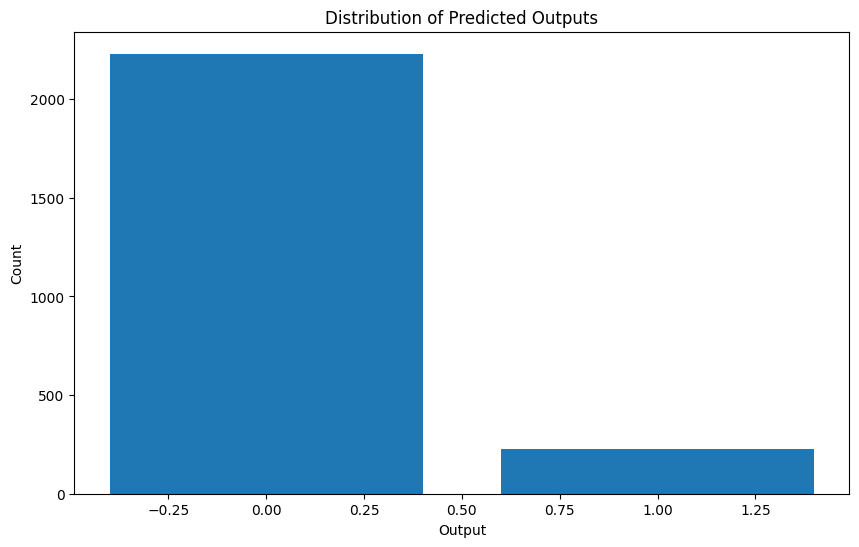

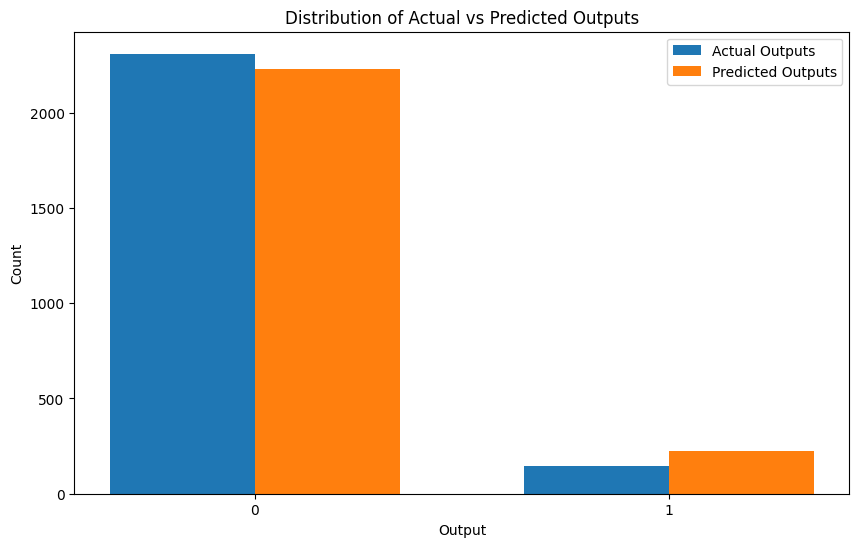

In [19]:
# Count the occurrences of each class in y_test and y_pred
unique_classes = list(set(y_test).union(set(y_pred)))
y_test_counts = [list(y_test).count(cls) for cls in unique_classes]
y_pred_counts = [list(y_pred).count(cls) for cls in unique_classes]

# Plotting the bar chart for actual outputs
plt.figure(figsize=(10, 6))
plt.bar(unique_classes, y_test_counts)
plt.xlabel('Output')
plt.ylabel('Count')
plt.title('Distribution of Actual Outputs')
plt.show()

# Plotting the bar chart for predicted outputs
plt.figure(figsize=(10, 6))
plt.bar(unique_classes, y_pred_counts)
plt.xlabel('Output')
plt.ylabel('Count')
plt.title('Distribution of Predicted Outputs')
plt.show()

# Plotting a grouped bar chart to compare actual and predicted outputs
width = 0.35
x = np.arange(len(unique_classes))

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, y_test_counts, width, label='Actual Outputs')
rects2 = ax.bar(x + width/2, y_pred_counts, width, label='Predicted Outputs')

ax.set_xlabel('Output')
ax.set_ylabel('Count')
ax.set_title('Distribution of Actual vs Predicted Outputs')
ax.set_xticks(x)
ax.set_xticklabels(unique_classes)
ax.legend()

plt.show()